# FWI com Unets

In [18]:
%env XLA_FLAGS=--xla_gpu_cuda_data_dir=/home/fmn/miniconda3/pkgs/cuda-nvvm-tools-12.9.86-h4bc722e_2

env: XLA_FLAGS=--xla_gpu_cuda_data_dir=/home/fmn/miniconda3/pkgs/cuda-nvvm-tools-12.9.86-h4bc722e_2


In [19]:
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import clear_output


import numpy as np

import tensorflow as tf
from tensorflow.keras import  layers, Model

from geod67lib.unet import create_migration_map
from geod67lib.normalization import create_normalization_transforms
from geod67lib.plotting import plot_image, plot_seismogram
from geod67lib.wavefield import WaveSolverLayer, AquisitionParameters, generate_damp_mask

## Modelo de velocidade e imagem migrada

In [20]:
# shape = (1024, 512)
# shape = (256, 256)
# spacing = (10, 10)
shape = (128, 128)
spacing = (20, 20)

width, height = (shape[0] - 1)*spacing[0], (shape[1] - 1)*spacing[1]

In [21]:
vp_true = np.fromfile(f'./data/marmo_vp_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
vp_0 = np.fromfile(f'./data/vp0_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))
zeta = np.fromfile(f'./data/mig_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape((1, shape[0], shape[1], 1))

In [22]:
vpmin = vp_true.min()*.9
vpmax = vp_true.max()*1.1

vpmin, vpmax

(np.float32(1.3499999), np.float32(4.895))

In [23]:
normalize, denormalize = create_normalization_transforms(vpmin, vpmax)

In [24]:
m_0 = normalize(tf.constant(vp_0))

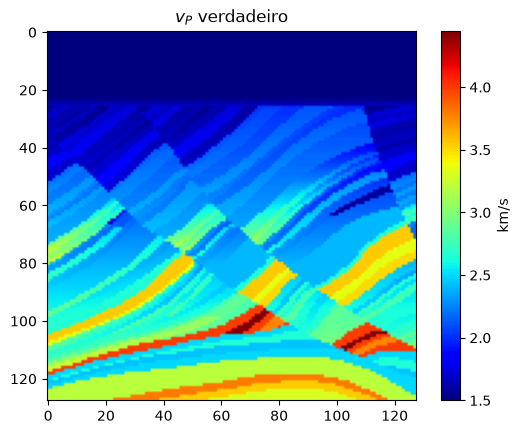

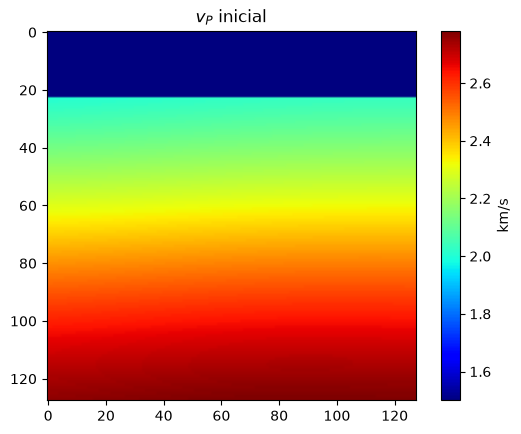

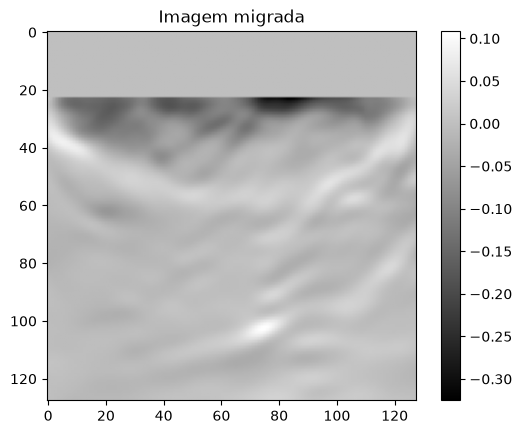

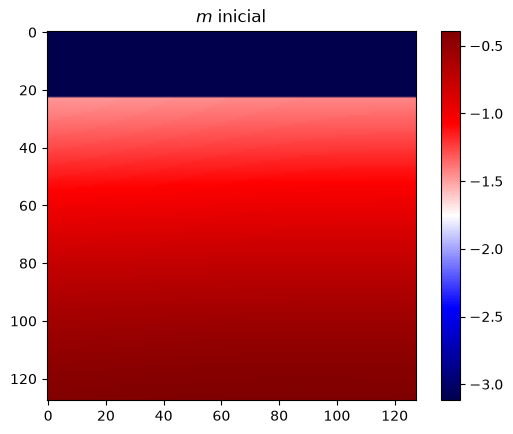

In [25]:
plot_image(vp_true, title='$v_P$ verdadeiro', label='km/s')
plot_image(vp_0, title='$v_P$ inicial', label='km/s')
plot_image(zeta, title='Imagem migrada', cmap='gray')
plot_image(m_0.numpy(), title='$m$ inicial', cmap='seismic')

## Construção da Rede

In [26]:
migmap = create_migration_map(*shape)

In [27]:
zeta_in = tf.constant(zeta)
np.min(zeta_in), np.max(zeta_in)

(np.float32(-0.32519037), np.float32(0.10902375))

In [28]:
dm = migmap(zeta_in)
np.min(dm), np.max(dm)

(np.float32(-0.004595183), np.float32(0.18377337))

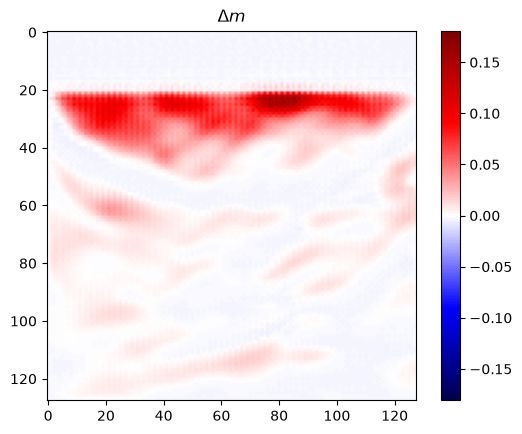

In [29]:
d = dm.numpy()
d = d - np.median(d)
plot_image(d, cmap='seismic', vmin=-np.abs(d).max(), vmax=np.abs(d).max(), title='$\\Delta m$')

## Operador de modelagem

In [30]:
nbl = 20

In [31]:
ap = AquisitionParameters.load('./data/aquisition-params.json')

nrec = ap.nrec
nsrc = ap.nsrc
nt = ap.nt

src_positions = ap.src_positions
ap.src_positions = np.zeros((1, 2))

In [32]:
vp0_pad = np.pad(vp_0[0, :, :, 0], nbl, mode='edge')
vp0_pad = vp0_pad.reshape((1, *vp0_pad.shape, 1))
damp_mask = generate_damp_mask(vp0_pad, nbl)

In [33]:
damp_mask.shape

(1, 168, 168, 1)

## Dado observado

In [34]:
dobs = np.fromfile(f'./data/dobs_nx{shape[0]}nz{shape[1]}dx{spacing[0]}dz{spacing[1]}.bin', dtype=np.float32).reshape(nsrc, nrec, nt)

In [35]:
slider = widgets.IntSlider(min=0, max=nsrc-1, description='Shot index')
@widgets.interact(idx=slider)
def plot_seismogram_interact(idx):
    plot_seismogram(dobs[idx], width, ap.tn)

interactive(children=(IntSlider(value=0, description='Shot index', max=4), Output()), _dom_classes=('widget-in…

## Inversão

In [36]:
migmap.input, migmap.output

(<KerasTensor shape=(None, 128, 128, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_45>,
 <KerasTensor shape=(None, 128, 128, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_89>)

In [37]:
dm = migmap.output
m = layers.Add()([dm, m_0])
out = WaveSolverLayer(ap, damp_mask, src_positions, spacing=spacing)(m)
out

<KerasTensor shape=(5, 128, 2000), dtype=float32, sparse=False, ragged=False, name=keras_tensor_91>

In [38]:
model = Model(inputs=migmap.input,outputs=out,name='train_net')
model

<Functional name=train_net, built=True>

In [39]:
model.output

<KerasTensor shape=(5, 128, 2000), dtype=float32, sparse=False, ragged=False, name=keras_tensor_91>

In [40]:
with tf.GradientTape() as g:
    dcalc = model(zeta_in)
    res = dcalc - dobs
    phi = tf.reduce_mean(tf.square(res))

    grad = g.gradient(phi, model.variables[0])
grad

<tf.Tensor: shape=(3, 3, 1, 8), dtype=float32, numpy=
array([[[[-1.82737239e-07, -4.29543143e-05,  8.04612500e-06,
          -2.48101114e-05, -4.46744780e-05, -1.45799568e-05,
           3.40921470e-05, -4.01477009e-05]],

        [[-2.91864467e-07, -4.28902276e-05,  7.04527520e-06,
          -2.23499228e-05, -4.07451880e-05, -1.27071526e-05,
           3.17261511e-05, -3.70011912e-05]],

        [[-2.02313899e-07, -4.07561383e-05,  6.53003917e-06,
          -1.94483655e-05, -3.56688470e-05, -1.11075833e-05,
           2.85361548e-05, -3.26438894e-05]]],


       [[[-1.47029709e-07, -4.34615140e-05,  8.04080446e-06,
          -2.49980840e-05, -4.44766374e-05, -1.44058995e-05,
           3.47463429e-05, -4.01220168e-05]],

        [[-2.09391700e-07, -4.33202877e-05,  7.11709072e-06,
          -2.23822099e-05, -4.05045721e-05, -1.24935159e-05,
           3.21610642e-05, -3.68431320e-05]],

        [[-1.00371210e-07, -4.10722059e-05,  6.62760249e-06,
          -1.93950727e-05, -3.55265656

In [41]:
model.compile(
    loss=tf.keras.losses.MeanSquaredError(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=[
        tf.keras.metrics.MeanSquaredError()
    ]
)

In [42]:
x_train = zeta
y_train = dobs.reshape((1, *dobs.shape))

In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size=1,
    epochs=1
)

Epoch 1/5


1/1 ━━━━━━━━━━━━━━━━━━━━ 1866s 1866s/step - loss: 18.8337 - mean_squared_error: 18.8337
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: nan - mean_squared_error: nan
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: nan - mean_squared_error: nan
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: nan - mean_squared_error: nan
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: nan - mean_squared_error: nan


In [44]:
dm = migmap(zeta)

In [45]:
dm

<tf.Tensor: shape=(1, 128, 128, 1), dtype=float32, numpy=
array([[[[nan],
         [nan],
         [nan],
         ...,
         [nan],
         [nan],
         [nan]],

        [[nan],
         [nan],
         [nan],
         ...,
         [nan],
         [nan],
         [nan]],

        [[nan],
         [nan],
         [nan],
         ...,
         [nan],
         [nan],
         [nan]],

        ...,

        [[nan],
         [nan],
         [nan],
         ...,
         [nan],
         [nan],
         [nan]],

        [[nan],
         [nan],
         [nan],
         ...,
         [nan],
         [nan],
         [nan]],

        [[nan],
         [nan],
         [nan],
         ...,
         [nan],
         [nan],
         [nan]]]], shape=(1, 128, 128, 1), dtype=float32)>